## Import necessary librairies

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# for evaluation
from sklearn.metrics import accuracy_score, classification_report

## Load dataset (Finance Loan approval prediction data)

In [67]:
finance_path = "loan_prediction/train.csv"

try:
    loan_data = pd.read_csv(finance_path)
except FileNotFoundError:
    print(f"Erreur sur le chargement du dataset")

## Dataset information

In [68]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB



## Initial Information About The Dataset 🧪

### This comment signifies that we are going to display initial information of the dataset to get a glimpse of the data's structure and values.

    * Displaying the first few rows of the dataset to get a glimpse of the data.
    * Checking the shape of the dataset (number of rows and columns).
    * Exploring the column names and data types.
    * Descriptive Statistics includes:
        - Numeric Variables.
        - Categorical Variables.

In [69]:
# displaying data with 7 rows
first_seven_rows = loan_data.head(7)

In [70]:
for index, row in first_seven_rows.iterrows():
    print(row)
    print("--------------------------------")

Loan_ID              LP001002
Gender                   Male
Married                    No
Dependents                  0
Education            Graduate
Self_Employed              No
ApplicantIncome          5849
CoapplicantIncome         0.0
LoanAmount                NaN
Loan_Amount_Term        360.0
Credit_History            1.0
Property_Area           Urban
Loan_Status                 Y
Name: 0, dtype: object
--------------------------------
Loan_ID              LP001003
Gender                   Male
Married                   Yes
Dependents                  1
Education            Graduate
Self_Employed              No
ApplicantIncome          4583
CoapplicantIncome      1508.0
LoanAmount              128.0
Loan_Amount_Term        360.0
Credit_History            1.0
Property_Area           Rural
Loan_Status                 N
Name: 1, dtype: object
--------------------------------
Loan_ID              LP001005
Gender                   Male
Married                   Yes
Dependents        

In [71]:
# show the data shape and dimensions
loan_rows = loan_data.shape[0]
loan_columns = loan_data.shape[1]
loan_dim = loan_data.ndim
loan_elements = loan_rows * loan_columns

print(f"Number of rows {loan_rows}")
print(f"Number of columns {loan_columns}")
print(f"Dimension of the dataset: {loan_dim}")
print(f"Number of elements {loan_elements}")

Number of rows 614
Number of columns 13
Dimension of the dataset: 2
Number of elements 7982


In [72]:
print(loan_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [73]:
# describe the data
loan_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


    count = The number of non-null values.
    mean = Avarage.
    Standard Deviation (std)= A measure of the spread of the variable's values around the mean. A higher standard deviation indicates greater variability in the data.
    min = The smallest value.
    25% = It represents the value below which 25% of the data fall
    50% = It represents the value below which 50% of the data fall
    75% = It represents the value below which 75% of the data fall
    max = The largest value.

In [74]:
# describe the data include the variable object
loan_data.describe(include=object).T

,count,unique,top,freq
Loan_ID,614,614,LP001002,1
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


# Data exploratory analysis
### Exploratory Data Analysis (EDA), is an essential step in the machine learning pipeline. It involves examining and visualizing the characteristics of a dataset to gain insights, understand patterns, detect anomalies, and prepare the data for further analysis and modeling. some common techniques used in data exploration:

    * Data Visualization
    * Data Cleaning
    * Data Preprocessing

## Data visualization

Creating visual representations such as histograms,scatter plots, box plots, and heatmaps to explore the distribution, relationships, and trends within the dataset. Visualization aids in identifying patterns, correlations, and potential insights that may not be apparent from just looking at the raw data. there are some ways to discover it:

    Graphical Analysis
        Bar Charts
        Pie Charts
        Histograms
    Correlation Analysis
    Data Relationships Analysis

## 1) Graphical analysis

In [75]:
loan_data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [76]:
loan_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64


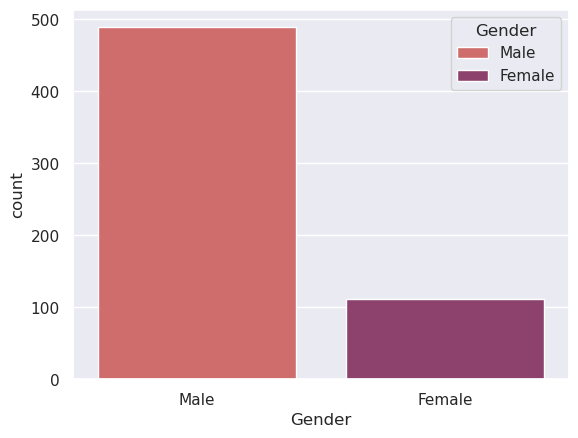

In [77]:
# si la variable est de type catégorielle: on utilise value_counts() - sns.countplot(), pie(), barplot()
# pour les variables de types numérique: histplot(),

# dropna=False, créer un graphique sans les valeurs manquantes
GenderAnalysis = loan_data.Gender.value_counts(dropna=False)
print(GenderAnalysis)

# Bar chart Analysis for Gender Features, countplot()
sns.countplot(x="Gender", data=loan_data, palette="flare", hue="Gender")
plt.show()

Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64


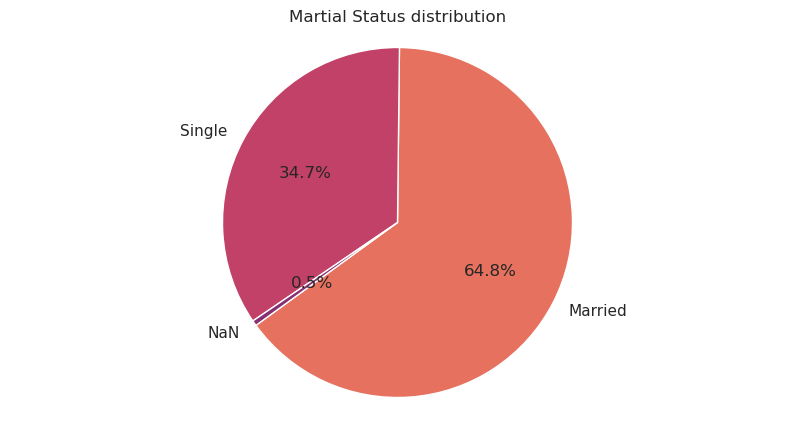

In [78]:
# "dropna" as False to count NaN values
MarriedAnalysis = loan_data.Married.value_counts(dropna=False)
print(MarriedAnalysis)

# Create pie chart For Married feature
plt.figure(figsize=(10, 5))

plt.pie(MarriedAnalysis,
        labels=[("Married"), ("Single"), ("NaN")],
        startangle=216,
        autopct='%1.1f%%',
        colors=sns.color_palette("flare", 
        len(MarriedAnalysis))
       )

plt.axis('equal')
plt.title("Martial Status distribution")
plt.show()

Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64


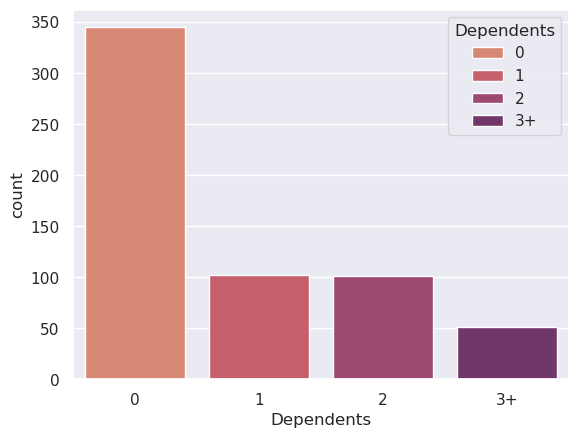

In [79]:
# dropna = False to count NaN values
DependentAnalysis = loan_data.Dependents.value_counts(dropna=False)
print(DependentAnalysis)

# Bar charts for dependentAnalysis
sns.countplot(x="Dependents", data=loan_data, palette="flare", hue="Dependents")
plt.show()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


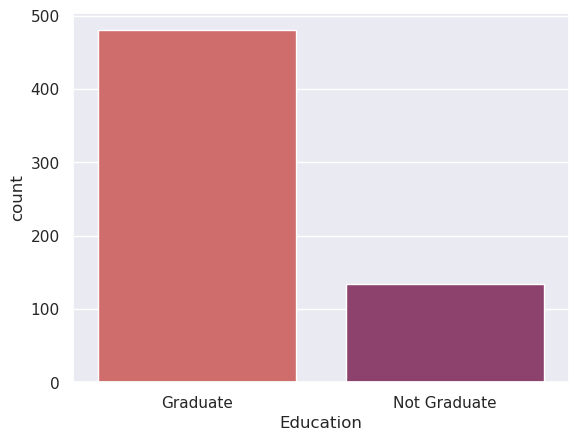

In [80]:
# 
educationAnalysis = loan_data.Education.value_counts(dropna=False)
print(educationAnalysis)

# 
sns.countplot(x="Education", data=loan_data, palette="flare", hue="Education")
plt.show()

Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64


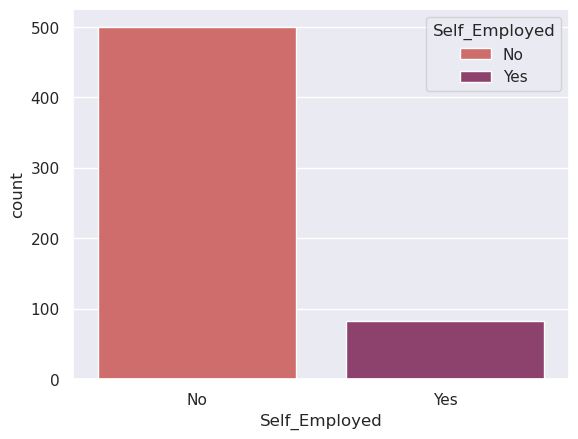

In [81]:
# "dropna" as False to count NaN values
Self_EmployedAnalysis = loan_data.Self_Employed.value_counts(dropna=False)
print(Self_EmployedAnalysis)

# Bar Charts Analysis "For Self Employed feature"
sns.countplot(x="Self_Employed", data=loan_data, palette="flare", hue="Self_Employed")
plt.show()

In [82]:
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


The average income: 5403.46
The higher average: 176, the minus average: 438
Average of higher and minus average: 0.4018264840182648


/tmp/ipykernel_8845/2178632027.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Above average", "Below average"], y=[higher_average_income, minus_average_income], palette="flare")


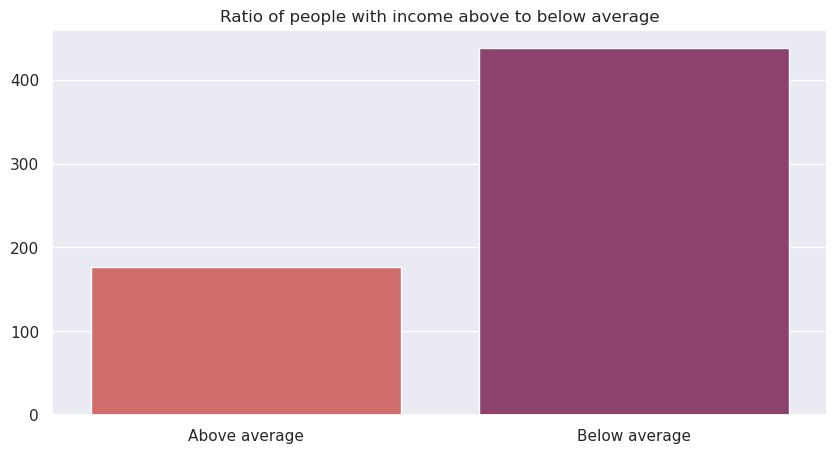

In [83]:
# calculate the average income
average_income = loan_data.ApplicantIncome.mean()
print(f"The average income: {average_income:.2f}")

# Count the income minus the average income and the higher income
higher_average_income = (loan_data.ApplicantIncome > average_income).sum()
minus_average_income = (loan_data.ApplicantIncome <= average_income).sum()
print(f"The higher average: {higher_average_income}, the minus average: {minus_average_income}")

# ratio sert à voir si les deux variables sont proportionnelles ou non, si la valeur est proche de 1 alors la première valeur est beaucoup plus grand, si la valeur est inférieure à 1 alors la seconde est plus grande
ratio_average = higher_average_income / minus_average_income
print(f"Average of higher and minus average: {ratio_average}")

# Plot the ratio using seaborn
plt.figure(figsize=(10, 5))
sns.barplot(x=["Above average", "Below average"], y=[higher_average_income, minus_average_income], palette="flare")
plt.title("Ratio of people with income above to below average")
plt.show()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


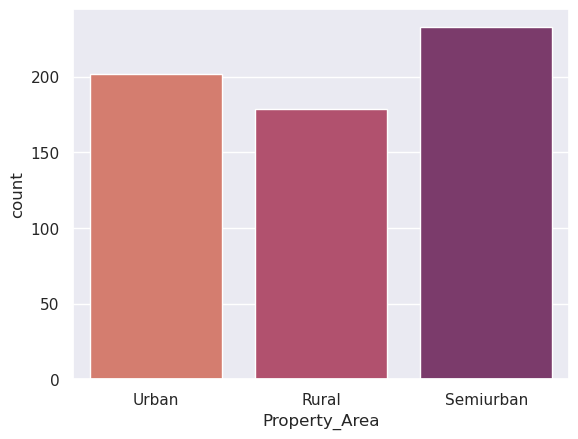

In [84]:
# property area
property_area = loan_data.Property_Area.value_counts(dropna=False)
print(property_area)

sns.countplot(x="Property_Area", data=loan_data, palette="flare", hue="Property_Area")
plt.show()
# loan status

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64


/tmp/ipykernel_8845/2392633320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Credit_History", data=loan_data, palette="flare")


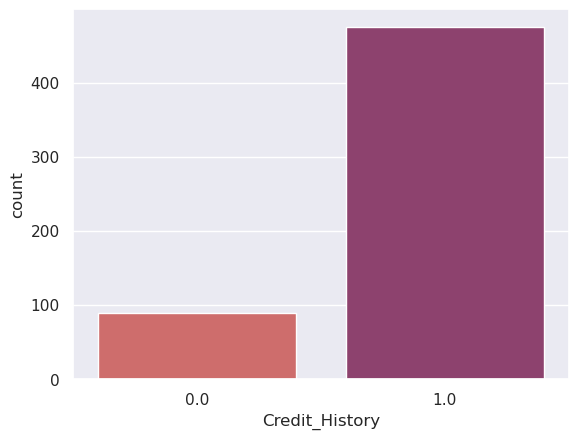

In [85]:
# "dropna" as False to count NaN values
Credit_HistoryAnalysis = loan_data.Credit_History.value_counts(dropna=False)
print(Credit_HistoryAnalysis)

# Bar Charts Analysis "For Credit History feature"
sns.countplot(x="Credit_History", data=loan_data, palette="flare")
plt.show()

Loan_Status
Y    422
N    192
Name: count, dtype: int64


/tmp/ipykernel_8845/347353585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status", data=loan_data, palette="flare")


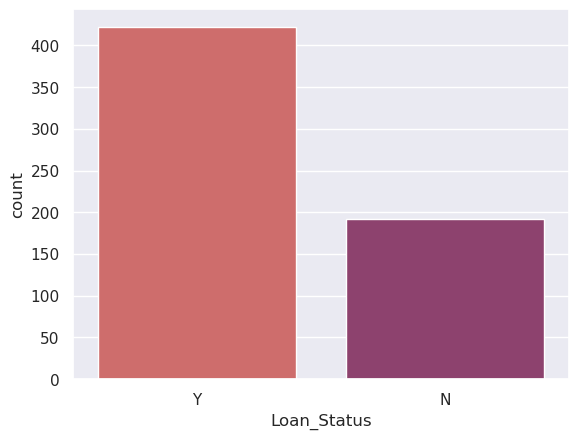

In [86]:
# "dropna" as False to count NaN values
Loan_StatusAnalysis = loan_data.Loan_Status.value_counts(dropna=False)
print(Loan_StatusAnalysis)

# Bar Charts Analysis "For Loan Status column"
sns.countplot(x="Loan_Status", data=loan_data, palette="flare")
plt.show()

### Interpretation: The number of approved loans is higher compared to rejected loans. It can also be seen. There is no missing values in this column

## Analyse des variables de type numérique

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
NaN       14
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


/tmp/ipykernel_8845/1130876095.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Amount_Term", data=loan_data, palette="flare")


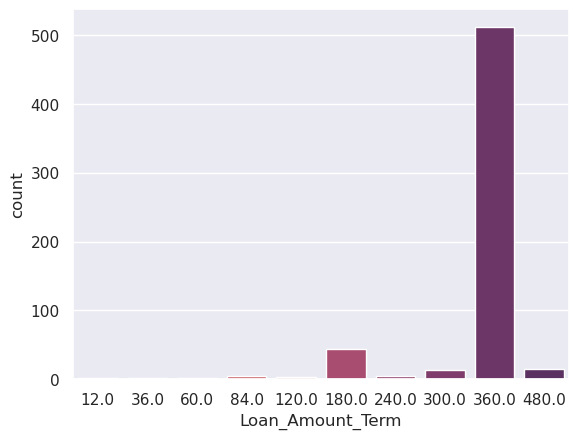

In [87]:
# "dropna" as False to count NaN values,
# loan_amount_term signifie la durée du remboursement du prêt
Loan_Amount_TermAnalysis = loan_data.Loan_Amount_Term.value_counts(dropna=False)
print(Loan_Amount_TermAnalysis)

# Bar Charts Analysis "For Loan amount term feature"
sns.countplot(x="Loan_Amount_Term", data=loan_data, palette="flare")
plt.show()

### Comme on peut le voir le remboursement du prêt est de 360 qui est la durée la plus populaire comparé aux autres

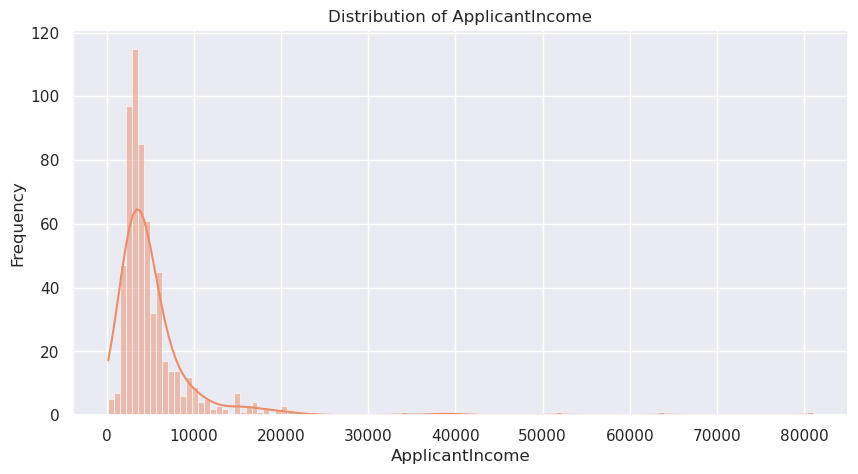

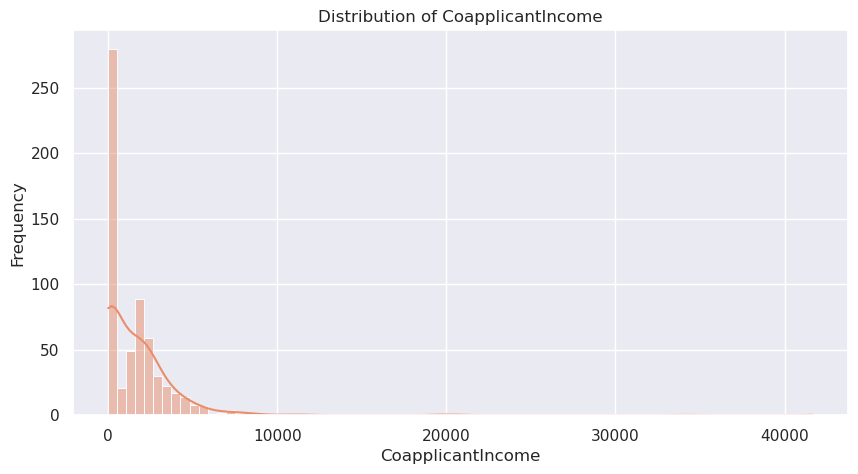

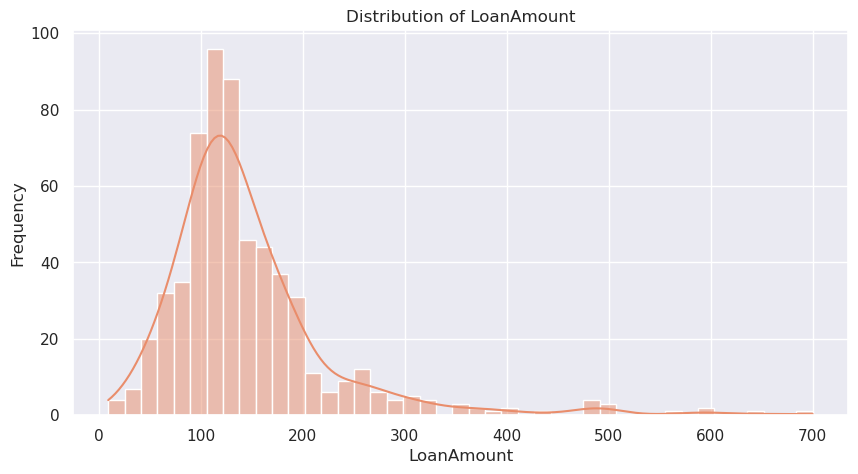

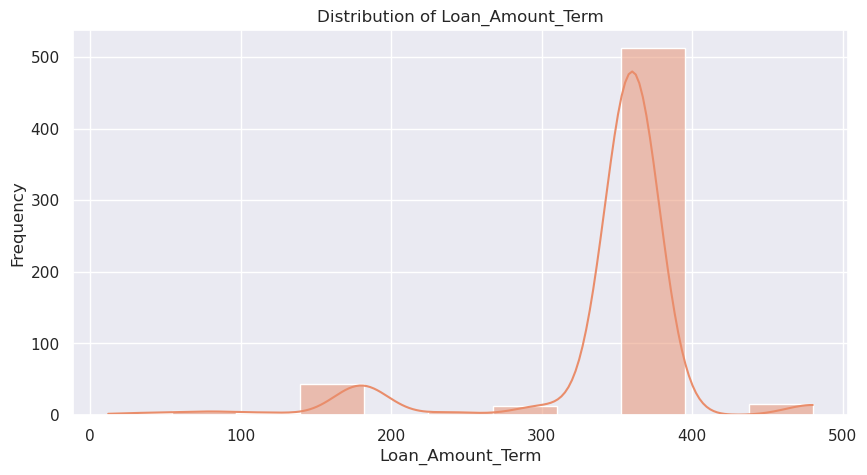

In [88]:
# histogram distribution des valeurs numériques, ça va nous permettre de voir s'il y a des outliers
sns.set_theme(palette="flare")

loan_numeric = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

loan_data_numeric = loan_data[loan_numeric]

for column in loan_data_numeric:
    plt.figure(figsize=(10, 5))
    plt.title(f"Distribution of {column}")
    sns.histplot(data=loan_data, x=column, kde=True)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.savefig(f"{column}_distribution.png")
    plt.show()
    plt.close()

### Cette analyse a révélé que la distribution des revenus du demandeur, du co-demandeur et du montant du prêt est positivement asymétrique (la plupart des valeurs sont regroupées autour de la queue gauche de la distribution, tandis que la queue droite est plus longue) et présente des valeurs aberrantes. En revanche, la distribution du montant du prêt à terme est négativement asymétrique et présente des valeurs aberrantes.

## 2) Correlation analysis

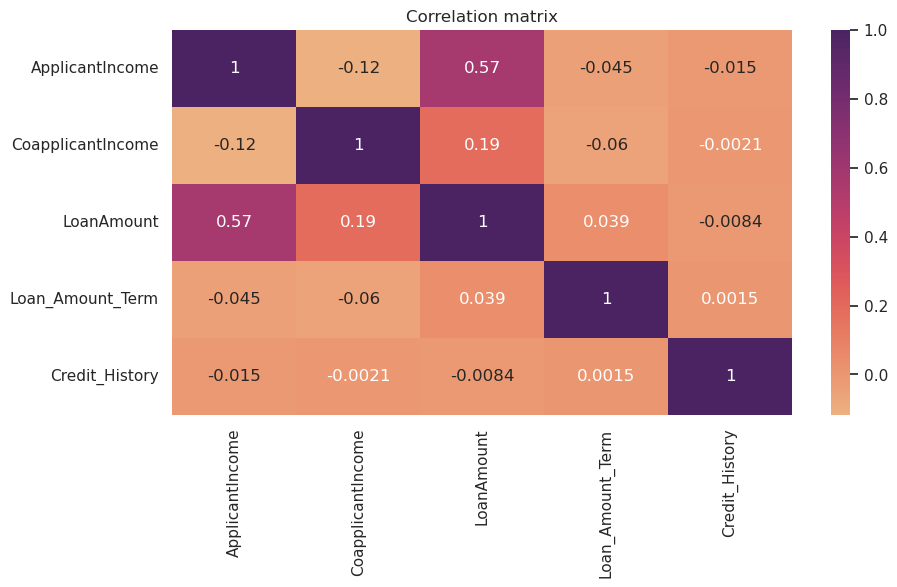

In [89]:
# correlation matrix using heatmap
loan_corr = loan_data.corr(numeric_only=True)

plt.figure(figsize=(10, 5))

# create a heatmap figure with specified size (in inches)
sns.heatmap(loan_corr, annot=True, cmap='flare')

plt.title("Correlation matrix")

plt.show()

plt.close()

## There is positive correlation between Loan Amount and Applicant Income

In [90]:
# matrice de corrélation pour les variables de types numérique, sns.heatmap()
# credit_history avec les valeurs 1 et 0, 1 signifie que le demandeur a un bon historique de crédit, 0 signifie un mauvais historique de crédit
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## 3) Data relationships (relation entre les variables catégorielles et la variable catégorielle target)
* c'est à dire entre 2 variables catégorielles

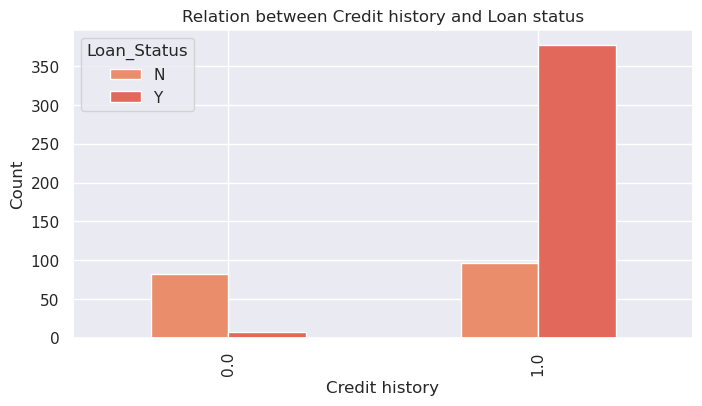

In [91]:
# entre variable catégorielle et variable numérique pd.crosstab()
# create a cross-tabulation of 'credit history' and 'Loan Status' variables, crosstab sert aussi à créer un tableau croisé
# fonction pd.crosstab est une fonction de pandas pour résumer et visualiser la relation entre deux ou plusieurs variables catégorielles
pd.crosstab(loan_data.Credit_History, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 4))

plt.title("Relation between Credit history and Loan status")

plt.xlabel("Credit history")

plt.ylabel("Count")

plt.show()

plt.close()

#### On peut voir sur la figure que la majorité des personnes qui ont un bon historique de crédit augmente leur chance d'être éligile pour avoir un prêt

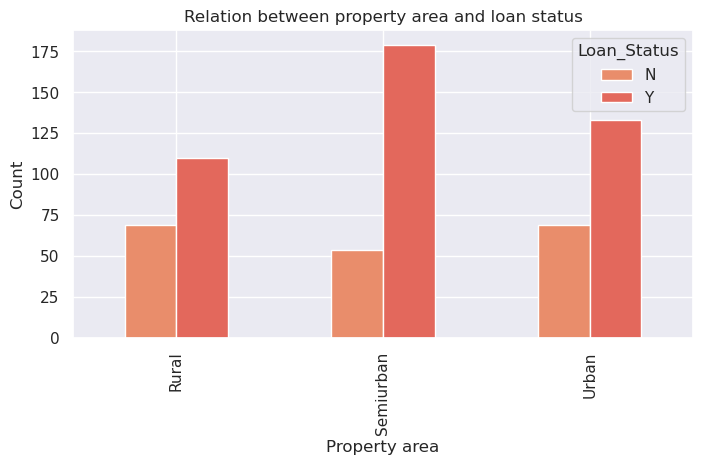

In [92]:
pd.crosstab(loan_data.Property_Area, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 4))

plt.title("Relation between property area and loan status")

plt.xlabel("Property area")

plt.ylabel("Count")

plt.show()

plt.close()

#### On remarque que ce qui ont des propriétés dans la partie semiurban sont nombreux à être éligible par rapport aux autres 

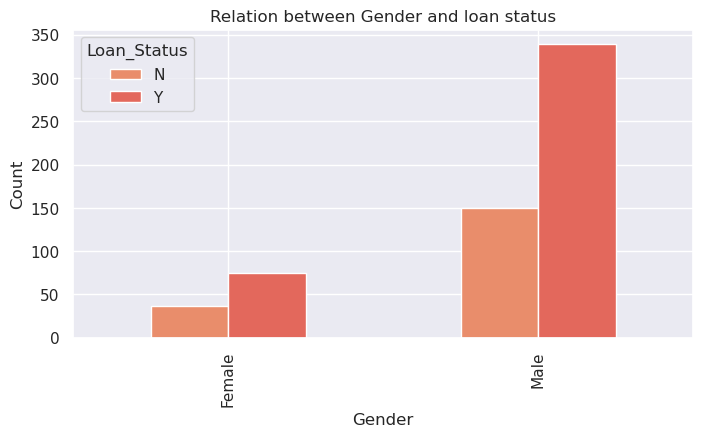

In [93]:
pd.crosstab(loan_data.Gender, loan_data.Loan_Status).plot(kind='bar', figsize=(8, 4))

plt.title("Relation between Gender and loan status")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

plt.close()

#### On remarque que les hommes qui sont mariées sont plus nombreux à être éligible au prêt par rapport au femme et c'est pareille au niveau des non éligibles

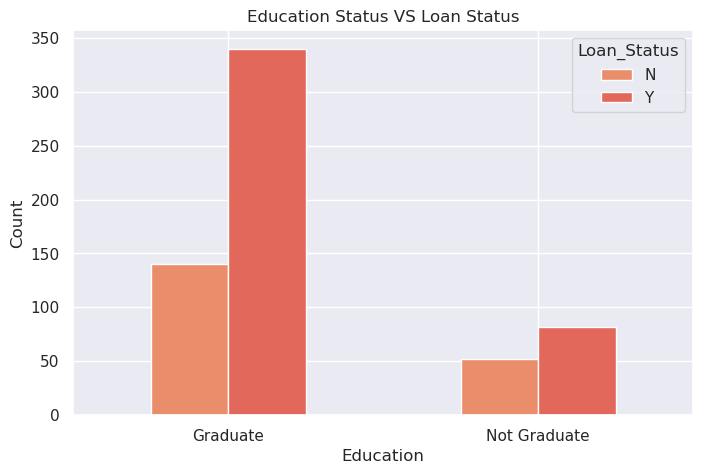

In [94]:
# Create a cross-tabulation of 'Gender' and 'Loan Status' variables
pd.crosstab(loan_data.Education, loan_data.Loan_Status).plot(kind="bar", figsize=(8, 5))

# Add a title to the plot
plt.title('Education Status VS Loan Status')

# Label the x-axis
plt.xlabel('Education')

# Label the y-axis
plt.ylabel('Count')

# Rotate the x-axis labels to avoid overlap
plt.xticks(rotation=0)

# Display the plot
plt.show()

#### L'analyse montre que les personnes diplômés sont éligibles à un prêt que les non diplômés

## Data cleaning

### Data cleaning est le processus d'identification, correction, supprimer les erreurs, les données inconsistents et l'inexactitude des données. Ça implique la transformation des données brutes en donnée format structuré pour de bon analyse, modelisation et d'autre tâche de data, celà inclus:
#### - Supprimer les variables qu'on a pas besoin
#### - traiter les valeurs manquantes
#### - encodage des variables catégorielles
#### - supprimer les valeurs abérrantes
#### - traiter les duplications

### 1) Supprimer les variables dont on a pas besoin

In [95]:
# suppression de la colonne loan_id
loan_data = loan_data.drop(['Loan_ID'], axis=1)

print(loan_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB
None


### 2) Traiter les valeurs manquantes 

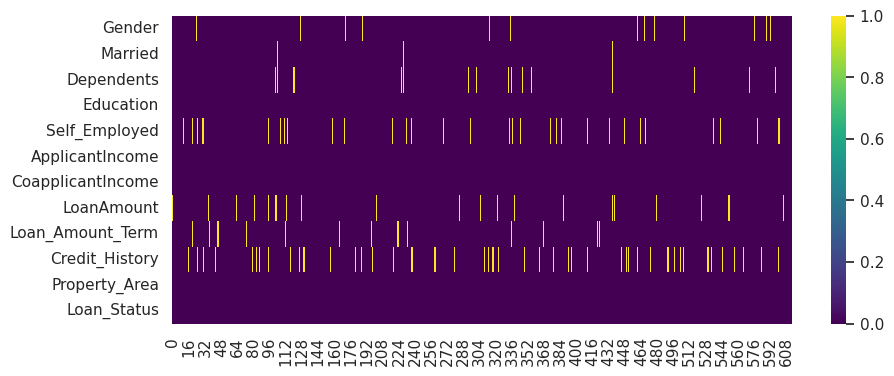

In [96]:
plt.figure(figsize=(10, 4))

sns.heatmap(data=loan_data.isnull().T, cmap='viridis', annot=False)

plt.show()

plt.close()

Les valeurs manquantes sont des points de données absents ou non enregistrés pour certaines variables d'un ensemble de données. Cela peut se produire en raison d'erreurs de saisie, de pannes d'équipement ou simplement parce que l'information n'est pas disponible.

Comment détecter les valeurs manquantes ?

Recherchez les cellules vides et utilisez des outils d'analyse de données capables d'identifier les valeurs manquantes, comme la fonction .isnull().

Options de décision :
Conservez-les.
Ce n'est pas idéal, car les valeurs manquantes peuvent entraîner des analyses biaisées et des prévisions inexactes.
Réaffectez-leur de nouvelles valeurs (à l'aide de techniques spécifiques).
Imputation (Y) :
Remplacez les valeurs manquantes par des valeurs estimées ou calculées en fonction des données disponibles. Cela peut être réalisé à l'aide de différentes méthodes, telles que :
Imputation moyenne/médiane : remplacez par la moyenne ou la valeur médiane pour les données numériques.
Imputation par mode : remplacez par la valeur la plus fréquente.
Remplissage avant/arrière (N) :

Pour les données de séries chronologiques, les valeurs manquantes peuvent être complétées par la dernière valeur observée (remplissage avant) ou la valeur observée suivante (remplissage arrière).

Interpolation (N) :

Estimer les valeurs manquantes en fonction de la tendance ou du modèle observé dans les points de données existants.

Supprimer les valeurs manquantes (parfois nécessaire, notamment si les valeurs manquantes sont nombreuses et ne peuvent être raisonnablement imputées sans introduire un biais significatif).

In [97]:
# dependents signifie: le nombre à charge du demandeur

In [98]:
# le nombre de nulle pour chaque colonne
print(loan_data.isnull().sum())

print(f"Nombre total de valeur manquantes: {loan_data.isnull().sum().sum()}")

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Nombre total de valeur manquantes: 149


#### There are two types of data:

####   - Numerical Data
####   - Categorical Data

### pour voir si une variable est symétrique ou non, on peut faire une test statistique en calculons le p-value en utilisant
from scipy.stats import shapiro
stat, p_value = shapiro(data['Income'])
print(p_value)

### Si p_value < 0.05 alors la variable n'est pas symétrique
### si la valeur manquante est moins de 5 pourcent on peut supprimer les lignes
### est ce qu'il faut voir ce 5 pourcent pour chaque colonne du dataset ou le dataset en entier
### entre 5 à 30 utilisé des méthodes avancés comme l'imputation
### plus de 30, considéré si la variable doit être supprimé ou non, ou bien nécessite d'autre hypothèse

In [99]:
loan_data_copy = loan_data.copy().dropna(axis=0)

print(loan_data.shape)
print(loan_data_copy.shape)
print(loan_data_copy.isnull().sum())

(614, 12)
(480, 12)
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


 Pourquoi choisir une méthode plutôt qu'une autre ?  

Le choix dépend de plusieurs facteurs : 

    Type de données  : Numérique, catégorique, ou mixte.
    Mécanisme de données manquantes  : MCAR, MAR, ou MNAR.
    Proportion de valeurs manquantes  : Moins de 5 %, entre 5 % et 30 %, ou plus de 30 %.
    Objectif de l'analyse  : Exploration descriptive, modélisation prédictive, ou prise de décision stratégique.
     

### Vérification des pourcentages des valeurs manquantes pour chaque variable

In [100]:
(loan_data.isnull().sum() * 100) / len(loan_data)

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

#### On remarque que pour la variable Self_Employed est plus de 5 pourcent de même pour la variable Credit_History, ça veut dire qu'ils nécessiteront des techniques d'imputation
#### Pour les autres on peut les traiter simplement

In [101]:
### Test de little: vérifie si les variables sont MCAR, MAR ou MNAR
#### - MCAR signifie: variable sans dépendance aux autres variables et sans dépendance à lui mêmes sur les valeurs manquantes elles mêmes
#### - MAR signifie: dépendances aux autres variables mais non dépendant de ses valeurs manquantes
#### - MNAR signifie: peut-être dépendant des autres variables et dépendent également des valeurs manquantes

In [102]:
from scipy.stats import ttest_ind

loan_data_copy = loan_data.select_dtypes(include=['float64'])

# Séparer les données complètes et incomplètes
complete_data = loan_data_copy.dropna()  # Lignes sans valeurs manquantes
incomplete_data = loan_data_copy[loan_data_copy.isnull().any(axis=1)]  # Lignes avec au moins une valeur manquante

# Tester pour chaque variable si les moyennes diffèrent significativement
for column in loan_data_copy.columns:
    if complete_data[column].notnull().any() and incomplete_data[column].notnull().any():
        # Test de Student pour comparer les moyennes
        stat, p_value = ttest_ind(
            complete_data[column].dropna(),
            incomplete_data[column].dropna(),
            equal_var=False  # Welch's t-test (variances non égales)
        )
        print(f"Variable: {column}, p-value: {p_value}")
        if p_value < 0.05:
            print(" -> Les données NE SONT PAS MCAR (différence significative).")
            print()
        else:
            print(" -> Les données semblent être MCAR.")
            print()

Variable: CoapplicantIncome, p-value: 0.2782216298330465
 -> Les données semblent être MCAR.

Variable: LoanAmount, p-value: 0.6834979122255482
 -> Les données semblent être MCAR.

Variable: Loan_Amount_Term, p-value: 0.7270341872044326
 -> Les données semblent être MCAR.

Variable: Credit_History, p-value: 0.09274111683030734
 -> Les données semblent être MCAR.



### Pour la variable LoanAmount, Loan_Amount_Term, Credit_History, ils sont MCAR (ne dépendent pas des autres variables et ne dépendent pas des valeurs manquantes elles mêmes)

<Axes: >

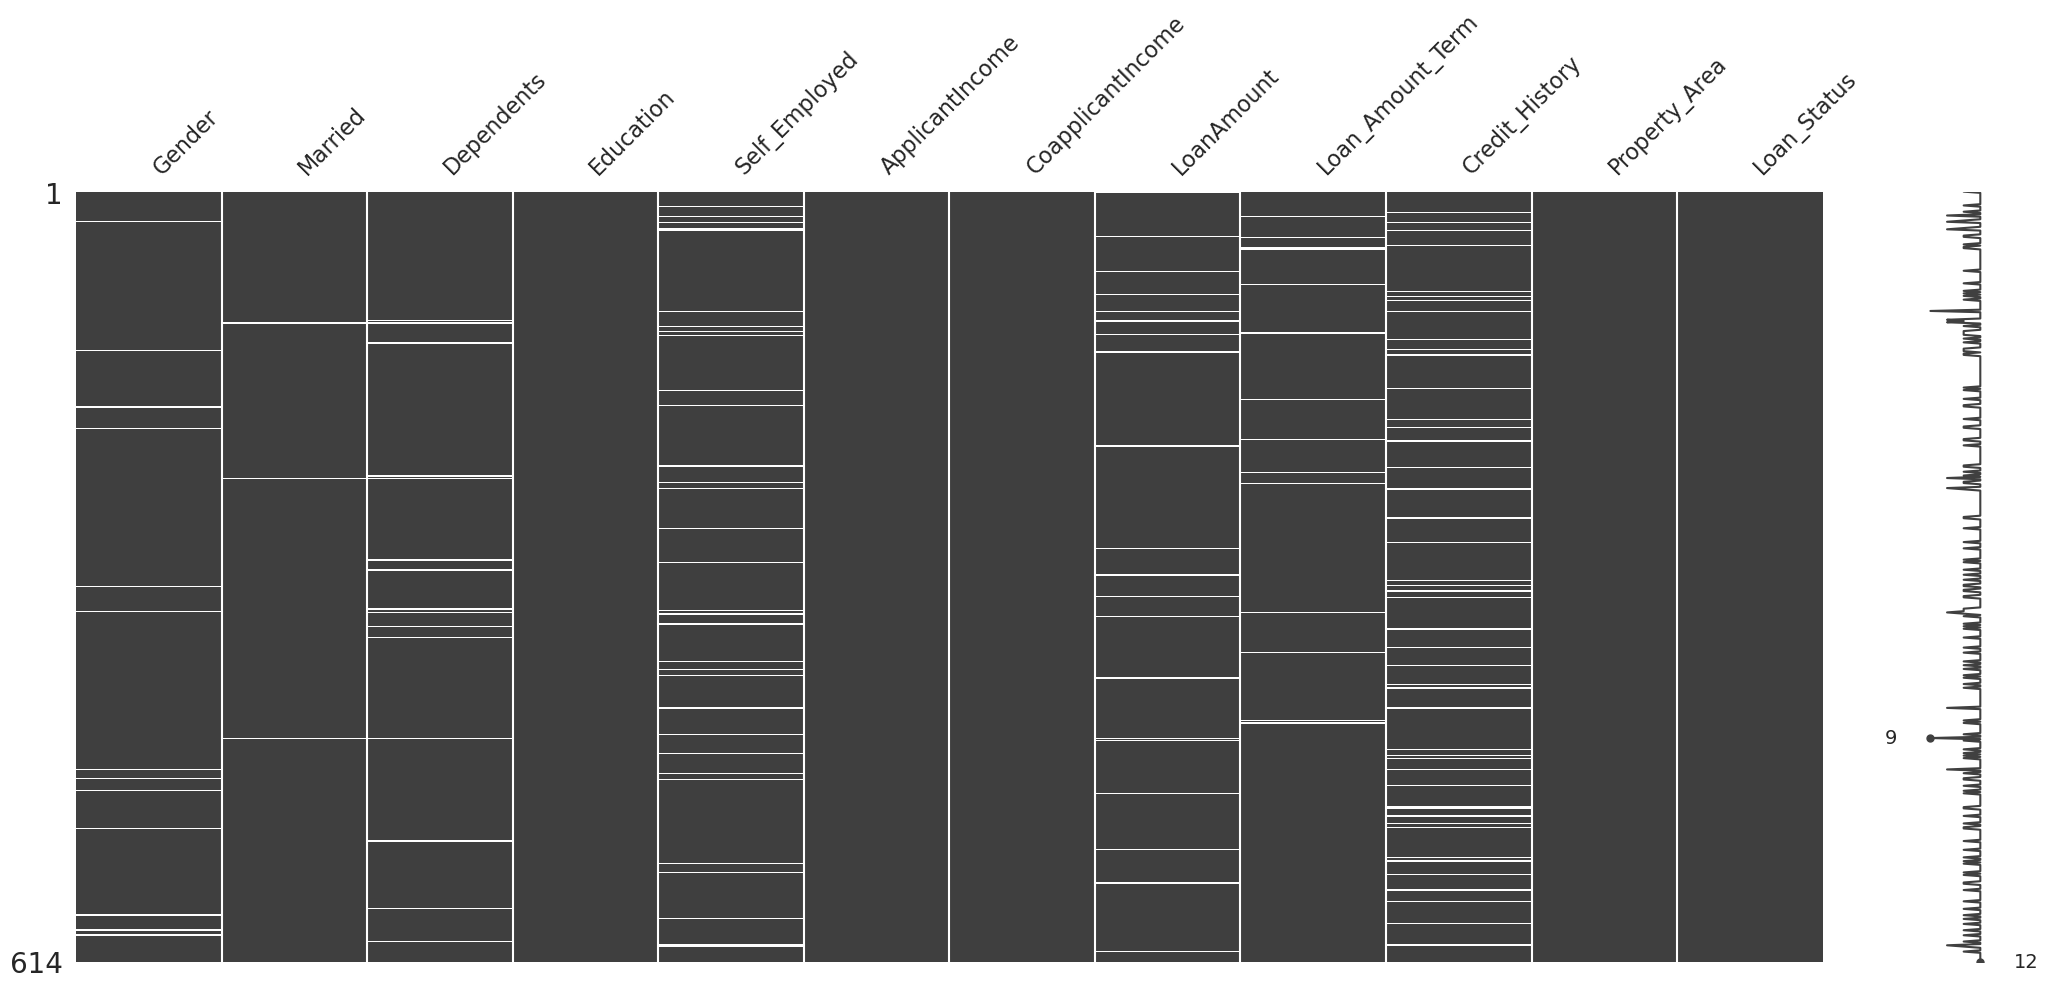

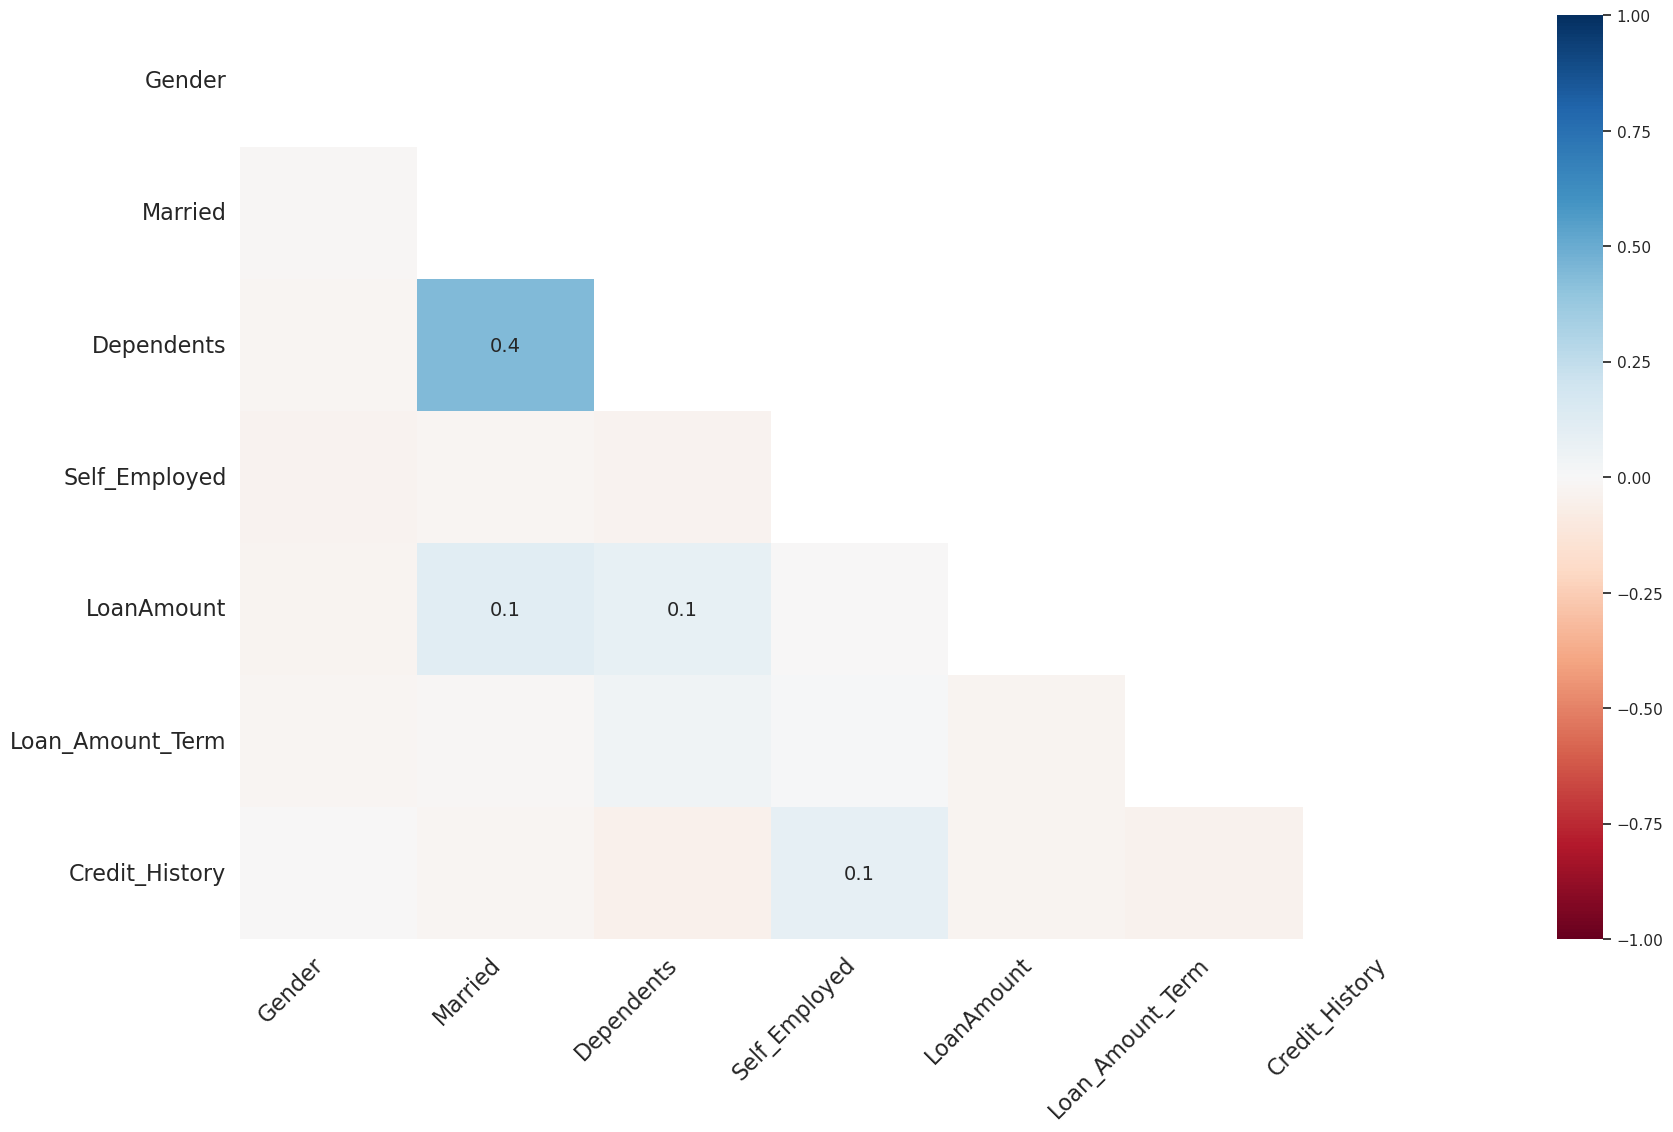

In [103]:
import missingno as msno

# Matrice de corrélation des valeurs manquantes
msno.matrix(loan_data)
msno.heatmap(loan_data)

#### Vérification des variables catégorielles s'ils sont MCAR, MAR ou MNAR

In [104]:
### Test de chi2 pour les variables catégorielles
# Test du chi2
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(loan_data['Married'], loan_data['Dependents'].isnull())
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p_value}")
if p_value < 0.05:
    print(" -> Les données ne sont pas MCAR.")
else:
    print(" -> Les données semblent être MCAR.")

p-value: 1.0
 -> Les données semblent être MCAR.


In [105]:
contingency_table = pd.crosstab(loan_data['LoanAmount'], loan_data['Dependents'].isnull())
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p_value}")
if p_value < 0.05:
    print(" -> Les données ne sont pas MCAR.")
else:
    print(" -> Les données semblent être MCAR.")

p-value: 0.9999991922680896
 -> Les données semblent être MCAR.


In [106]:
contingency_table = pd.crosstab(loan_data['Credit_History'], loan_data['Self_Employed'].isnull())
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p_value}")
if p_value < 0.05:
    print(" -> Les données ne sont pas MCAR.")
else:
    print(" -> Les données semblent être MCAR.")

p-value: 0.1516694825576357
 -> Les données semblent être MCAR.


In [107]:
### Imputation par le mode

In [108]:
#self_employed, gender, married, dependents
column_missing_value = ['Gender', 'Self_Employed', 'Dependents', 'Married']

for column in column_missing_value:
    loan_data[column] = loan_data[column].fillna(loan_data[column].mode()[0])

In [109]:
loan_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Imputation des variables numériques

In [110]:
# For the variable LoanAmount
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())

# For the variable Loan_Amount_Term
loan_data['Loan_Amount_Term'] = loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mode()[0])

# For the variable Credit_History
loan_data['Credit_History'] = loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0])

In [111]:
loan_data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 3) Encoding categorical variables

In [112]:
# Convert categorical variables into dummy/indicator variables through a process called "one-hot" encoding
loan_data = pd.get_dummies(loan_data)

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0       128.0             360.0   
1               4583             1508.0       128.0             360.0   
2               3000                0.0        66.0             360.0   
3               2583             2358.0       120.0             360.0   
4               6000                0.0       141.0             360.0   
..               ...                ...         ...               ...   
609             2900                0.0        71.0             360.0   
610             4106                0.0        40.0             180.0   
611             8072              240.0       253.0             360.0   
612             7583                0.0       187.0             360.0   
613             4583                0.0       133.0             360.0   

     Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  \
0               1.0          False         True

In [113]:
# Drop unneeded features
loan_data = loan_data.drop(['Gender_Female', 
                            'Married_No', 
                            'Education_Not Graduate',
                            'Self_Employed_No', 
                            'Loan_Status_N'], axis = 1) # axis = 1 for column

# Rename existing columns
newColunmsNames = {'Gender_Male': 'Gender', 
                   'Married_Yes': 'Married', 
                   'Education_Graduate': 'Education', 
                   'Self_Employed_Yes': 'Self_Employed',
                   'Loan_Status_Y': 'Loan_Status'}

# Assigning new columns names
loan_data = loan_data.rename(columns=newColunmsNames)

# Display the columns names and shape of the transformed dataset
## Get the column names of the DataFrame
column_names = loan_data.columns.tolist()

for col in column_names:
    print(f"- {col}")
    
print("The shape =",loan_data.shape)
print("_______________________________________________")

- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Gender
- Married
- Dependents_0
- Dependents_1
- Dependents_2
- Dependents_3+
- Education
- Self_Employed
- Property_Area_Rural
- Property_Area_Semiurban
- Property_Area_Urban
- Loan_Status
The shape = (614, 17)
_______________________________________________



## 4. Handling Outliers

Outliers are data points that significantly differ from the rest of the observations in a dataset, often due to errors in data collection or genuine extreme values.

How to detect outliers?

    Visualization data (Numerical values)

    Decision options:

    Keep them (Not the best solution, I try it and not get high accuracy, "There is better")
    Reassign new values to them (Using specific techniques)
        Capping Outliers (N)
            Instead of removing outliers entirely, replace extreme values with more reasonable thresholds.
        Robust Scaling (Y)
            Use scaling methods less sensitive to outliers (e.g., IQR scaling, standardization with robust estimators).
                Robust Scaling Function
                IQR scaling
        Replace with mean (N)
            Replacing the outliers with the mean value
    Delete them (N)

Showing outliers in this process before making any handling, but in another graph than the previous graph I used.


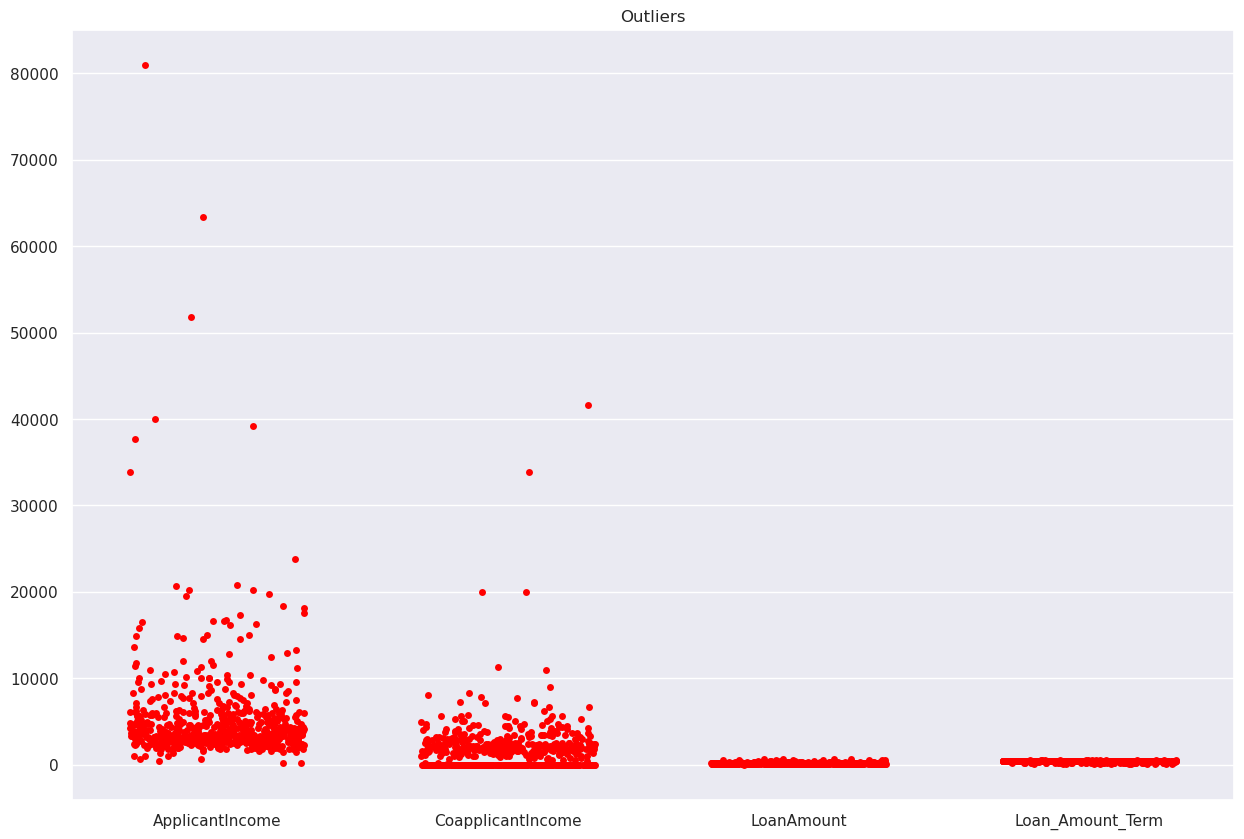

In [114]:
# Set the figure size
plt.figure(figsize=(15, 10))

# Only variables that have outliers
outliersColumns = loan_data.get(["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"])

# Add outliers to the plot
sns.stripplot(data=outliersColumns, color="red", jitter=0.3, size=5)

# Set the axis labels and title
plt.title("Outliers")

# Show the plot
plt.show()